**A. Membangun Struktur Direktori HDFS**

In [4]:
!hdfs dfs -mkdir -p /user/xcell/ecommerce/raw
!hdfs dfs -mkdir -p /user/xcell/ecommerce/processed
!hdfs dfs -ls -R /user/xcell/ecommerce

drwxr-xr-x   - xcell supergroup          0 2026-09-05 23:50 /user/xcell/ecommerce/processed
drwxr-xr-x   - xcell supergroup          0 2026-09-05 23:50 /user/xcell/ecommerce/raw


**B. Mengunggah Data Mentah ke HDFS**

In [5]:
!hdfs dfs -put transaksi_magelang.csv transaksi_yogyakarta.csv transaksi_semarang.csv /user/xcell/ecommerce/raw/
!hdfs dfs -ls -h /user/xcell/ecommerce/raw

Found 3 items
-rw-r--r--   1 xcell supergroup     12.0 K 2026-09-05 23:53 /user/xcell/ecommerce/raw/transaksi_magelang.csv
-rw-r--r--   1 xcell supergroup     11.9 K 2026-09-05 23:53 /user/xcell/ecommerce/raw/transaksi_semarang.csv
-rw-r--r--   1 xcell supergroup     12.4 K 2026-09-05 23:53 /user/xcell/ecommerce/raw/transaksi_yogyakarta.csv


**C. Membaca Kembali dan Menggabungkan Data dari HDFS**

In [6]:
import subprocess
import io
import pandas as pd

def baca_csv_dari_hdfs(path_hdfs):
    hasil = subprocess.run(["hdfs", "dfs", "-cat", path_hdfs], stdout=subprocess.PIPE)
    return pd.read_csv(io.BytesIO(hasil.stdout))

df_magelang = baca_csv_dari_hdfs("/user/xcell/ecommerce/raw/transaksi_magelang.csv")
df_yogyakarta = baca_csv_dari_hdfs("/user/xcell/ecommerce/raw/transaksi_yogyakarta.csv")
df_semarang = baca_csv_dari_hdfs("/user/xcell/ecommerce/raw/transaksi_semarang.csv")

df_gabungan = pd.concat([df_magelang, df_yogyakarta, df_semarang], ignore_index=True)
print(df_gabungan["kota"].value_counts())

kota
Magelang      200
Yogyakarta    200
Semarang      200
Name: count, dtype: int64


**D. Mengolah dan Download Hasil ke Direktori processed**

In [10]:
df_gabungan["total_pendapatan"] = df_gabungan["unit_terjual"] * df_gabungan["harga_satuan"]

ringkasan_kota_kategori = (
    df_gabungan.groupby(["kota", "kategori"])["total_pendapatan"]
    .sum()
    .reset_index()
    .sort_values(["kota", "total_pendapatan"], ascending=[True, False])
)

df_gabungan.to_csv("data_gabungan_bersih.csv", index=False)
ringkasan_kota_kategori.to_csv("ringkasan_kota_kategori.csv", index=False)

In [13]:
!hdfs dfs -put data_gabungan_bersih.csv ringkasan_kota_kategori.csv /user/xcell/ecommerce/processed/
!hdfs dfs -ls -h /user/xcell/ecommerce/processed

Found 2 items
-rw-r--r--   1 xcell supergroup     40.3 K 2026-09-06 00:03 /user/xcell/ecommerce/processed/data_gabungan_bersih.csv
-rw-r--r--   1 xcell supergroup        530 2026-09-06 00:03 /user/xcell/ecommerce/processed/ringkasan_kota_kategori.csv


**E. Dokumentasi dan Refleksi**

/user/xcell/ecommerce:
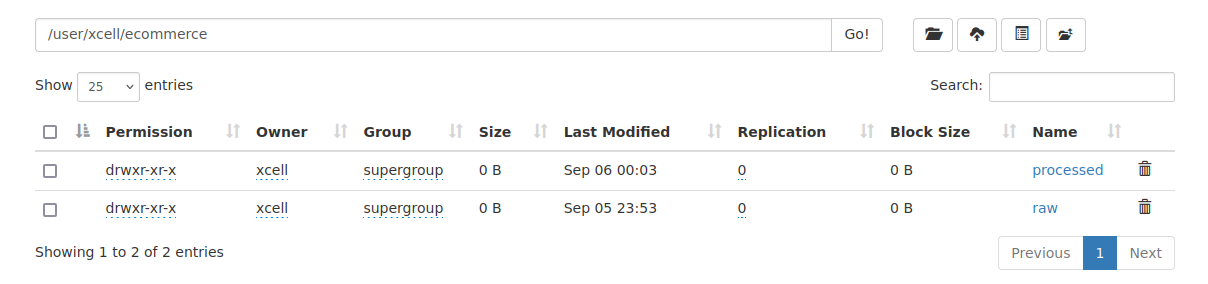

/user/xcell/ecommerce/processed
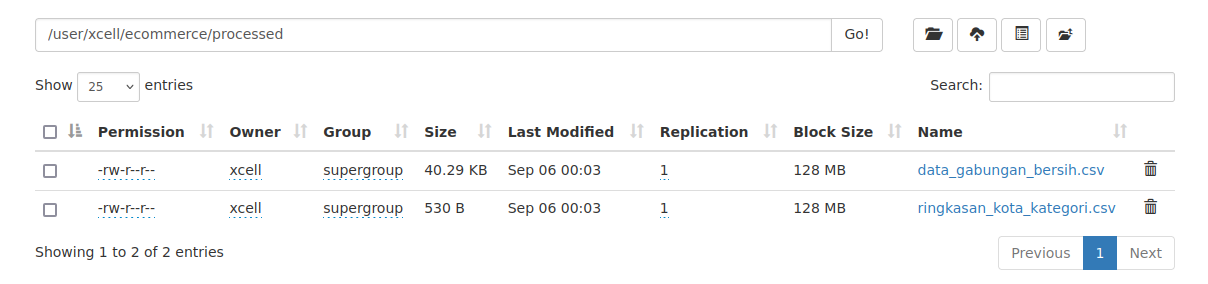

/user/xcell/ecommerce/raw
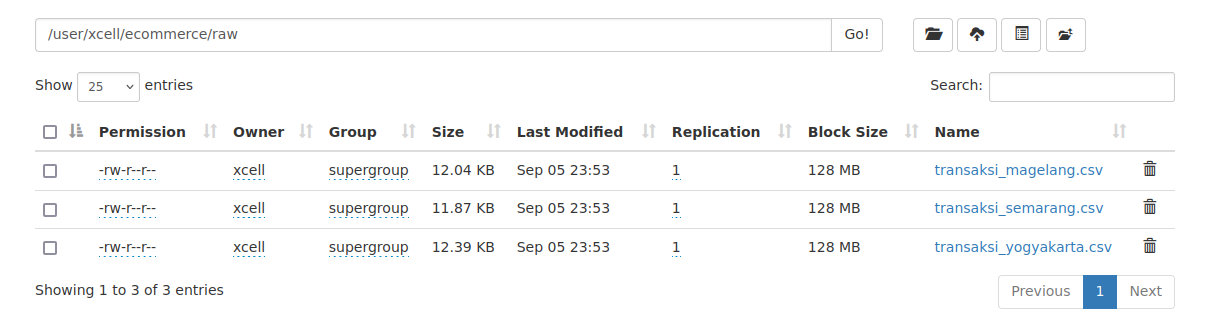

**Refleksi:**
Mengerjakan alur ini dari awal sampai akhir menunjukkan bahwa memindahkan data transaksi dari CSV lepas di laptop ke HDFS tidak sekadar soal "upload berkas" - perlu dipikirkan dulu struktur direktori (raw vs processed) supaya data mentah dan data hasil olahan tidak tercampur, dan tetap butuh kombinasi perintah shell (hdfs dfs) dengan kode Python untuk benar-benar memanfaatkan data yang sudah tersimpan di HDFS. Ini juga jadi fondasi yang masuk akal sebelum masuk ke tools big data lain (seperti Spark) di pertemuan-pertemuan berikutnya, karena keduanya nanti akan langsung membaca dari lokasi HDFS yang sudah disiapkan di tugas ini.